# Activity: Build a decision tree

## Introduction

A decision tree model can makes predictions for a target based on multiple features. Because decision trees are used across a wide array of industries, becoming proficient in the process of building one will help you expand your skill set in a widely-applicable way.   

For this activity, you work as a consultant for an airline. The airline is interested in predicting whether a future customer would be satisfied with their services given previous customer feedback about their flight experience. The airline would like you to construct and evaluate a model that can accomplish this goal. Specifically, they are interested in knowing which features are most important to customer satisfaction.

The data for this activity includes survey responses from 129,880 customers. It includes data points such as class, flight distance, and in-flight entertainment, among others. In a previous activity, you utilized a binomial logistic regression model to help the airline better understand this data. In this activity, your goal will be to utilize a decision tree model to predict whether or not a customer will be satisfied with their flight experience. 

Because this activity uses a dataset from the industry, you will need to conduct basic EDA, data cleaning, and other manipulations to prepare the data for modeling.

In this activity, you’ll practice the following skills:

* Importing packages and loading data
* Exploring the data and completing the cleaning process
* Building a decision tree model 
* Tuning hyperparameters using `GridSearchCV`
* Evaluating a decision tree model using a confusion matrix and various other plots

## Step 1: Imports

Import relevant Python packages. Use `DecisionTreeClassifier`,` plot_tree`, and various imports from `sklearn.metrics` to build, visualize, and evaluate the model.

### Import packages

In [1]:
# Standard operational package imports
import pandas as pd
import numpy as np

# Important imports for modeling and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Visualization package imports
import matplotlib.pyplot as plt
import seaborn as sns

### Load the dataset

`Pandas` is used to load the **Invistico_Airline.csv** dataset. The resulting pandas DataFrame is saved in a variable named `df_original`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.

df_original = pd.read_csv("Invistico_Airline.csv")

### Output the first 10 rows of data

In [3]:
df_original.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


## Step 2: Data exploration, data cleaning, and model preparation

### Prepare the data

After loading the dataset, prepare the data to be suitable for decision tree classifiers. This includes: 

*   Exploring the data
*   Checking for missing values
*   Encoding the data
*   Renaming a column
*   Creating the training and testing data

### Explore the data

Check the data type of each column. Note that decision trees expect numeric data. 

In [4]:
df_original.dtypes

satisfaction                          object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
dtype: obj

### Output unique values 

The `Class` column is ordinal (meaning there is an inherent order that is significant). For example, airlines typically charge more for 'Business' than 'Eco Plus' and 'Eco'. Output the unique values in the `Class` column. 

In [5]:
df_original['Class'].unique()

array(['Eco', 'Business', 'Eco Plus'], dtype=object)

### Check the counts of the predicted labels

In order to predict customer satisfaction, verify if the dataset is imbalanced. To do this, check the counts of each of the predicted labels. 

In [6]:
df_original['satisfaction'].value_counts(normalize=True)

satisfied       0.547328
dissatisfied    0.452672
Name: satisfaction, dtype: float64

**Question:** How many satisfied and dissatisfied customers were there?

There were approximately 54.7% satisfied customers and 45.3% dissatisfied customers, indicating a relatively balanced dataset.

**Question:** What percentage of customers were satisfied? 

Approximately 54.7% of customers were satisfied, showing that a slight majority of customers reported a positive experience.

### Check for missing values

The sklearn decision tree implementation does not support missing values. Check for missing values in the rows of the data. 

In [7]:
df_original.isna().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

**Question:** Why is it important to check how many rows and columns there are in the dataset?

It is important to check the number of rows and columns to understand the size and structure of the dataset. This helps in identifying whether there is sufficient data for modeling and ensures that any data cleaning steps, such as removing missing values, do not significantly reduce the dataset.

### Check the number of rows and columns in the dataset

In [8]:
df_original.isna().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

### Drop the rows with missing values

Drop the rows with missing values and save the resulting pandas DataFrame in a variable named `df_subset`.

In [9]:
df_subset = df_original.dropna()

### Check for missing values

Check that `df_subset` does not contain any missing values.

In [10]:
df_subset.isna().sum()

satisfaction                         0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

### Check the number of rows and columns in the dataset again

Check how many rows and columns are remaining in the dataset. You should now have 393 fewer rows of data.

In [11]:
df_subset.shape

(129487, 22)

### Encode the data

Four columns (`satisfaction`, `Customer Type`, `Type of Travel`, `Class`) are the pandas dtype object. Decision trees need numeric columns. Start by converting the ordinal `Class` column into numeric. 

In [12]:
df_subset['Class'] = df_subset['Class'].map({'Eco':0, 'Eco Plus':1, 'Business':2})

### Represent the data in the target variable numerically

To represent the data in the target variable numerically, assign `"satisfied"` to the label `1` and `"dissatisfied"` to the label `0` in the `satisfaction` column. 

In [13]:
df_subset['satisfaction'] = df_subset['satisfaction'].map({'dissatisfied':0, 'satisfied':1})

### Convert categorical columns into numeric

There are other columns in the dataset that are still categorical. Be sure to convert categorical columns in the dataset into numeric.

In [14]:
df_subset = pd.get_dummies(df_subset, drop_first=True)

### Check column data types

Now that you have converted categorical columns into numeric, check your column data types.

In [15]:
df_subset.dtypes

satisfaction                           int64
Age                                    int64
Class                                  int64
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Customer Type_disloyal Customer        uint8
Type of Travel_Personal Travel         uint8
dtype: obj

### Create the training and testing data

Put 75% of the data into a training set and the remaining 25% into a testing set. 

In [16]:
X = df_subset.drop(columns=['satisfaction'])
y = df_subset['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

## Step 3: Model building

### Fit a decision tree classifier model to the data

Make a decision tree instance called `decision_tree` and pass in `0` to the `random_state` parameter. This is only so that if other data professionals run this code, they get the same results. Fit the model on the training set, use the `predict()` function on the testing set, and assign those predictions to the variable `dt_pred`. 

In [17]:
decision_tree = DecisionTreeClassifier(random_state=0)

decision_tree.fit(X_train, y_train)

dt_pred = decision_tree.predict(X_test)

**Question:** What are some advantages of using decision trees versus other models you have learned about? 

Decision trees are easy to interpret and visualize, making them highly useful for understanding relationships in the data. They can handle both numerical and categorical variables, require minimal data preprocessing, and are capable of capturing non-linear relationships between features and the target variable.

## Step 4: Results and evaluation

Print out the decision tree model's accuracy, precision, recall, and F1 score.

In [18]:
accuracy_score(y_test, dt_pred), precision_score(y_test, dt_pred), recall_score(y_test, dt_pred), f1_score(y_test, dt_pred)

(0.9355924873347338, 0.9403490933740044, 0.941785471826205, 0.941066734503519)

**Question:** Are there any additional steps you could take to improve the performance or function of your decision tree?

Yes, performance can be improved through hyperparameter tuning, such as adjusting the maximum depth and minimum samples per leaf. Additionally, techniques such as pruning, feature selection, and using ensemble methods like Random Forests or Gradient Boosting can further enhance model performance.

### Produce a confusion matrix

Data professionals often like to know the types of errors made by an algorithm. To obtain this information, produce a confusion matrix.

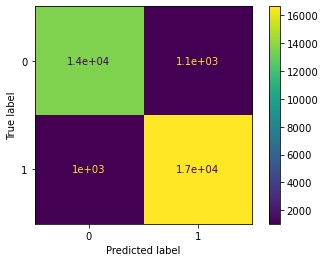

In [19]:
cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()


**Question:** What patterns can you identify between true positives and true negatives, as well as false positives and false negatives?

The confusion matrix shows a high number of true positives and true negatives, indicating strong overall model performance. The number of false positives and false negatives is relatively low, suggesting that the model makes few incorrect classifications. This pattern aligns with the high accuracy, precision, recall, and F1 score observed.

### Plot the decision tree

Examine the decision tree. Use `plot_tree` function to produce a visual representation of the tree to pinpoint where the splits in the data are occurring.

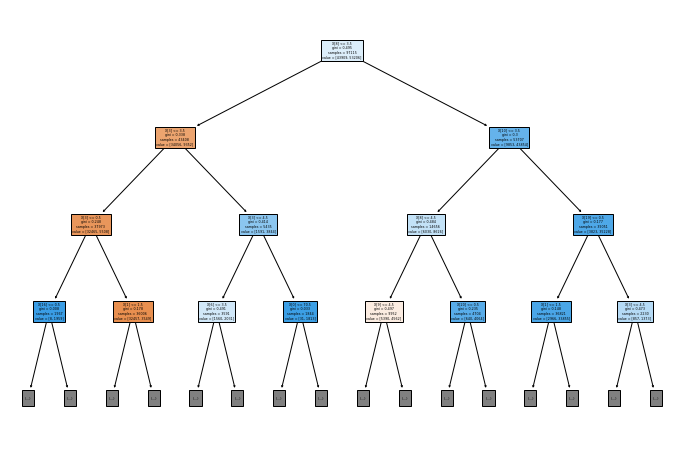

In [20]:
plt.figure(figsize=(12,8))
plot_tree(decision_tree, max_depth=3, filled=True)
plt.show()

### Hyperparameter tuning

Knowing how and when to adjust or tune a model can help a data professional significantly increase performance. In this section, you will find the best values for the hyperparameters `max_depth` and `min_samples_leaf` using grid search and cross validation. Below are some values for the hyperparameters `max_depth` and `min_samples_leaf`.   

In [21]:
tree_para = {
    'max_depth': [2,3,4,5,6,7,8,9,10],
    'min_samples_leaf': [2,3,4,5,10]
}

scoring = {'accuracy', 'precision', 'recall', 'f1'}

tuned_decision_tree = DecisionTreeClassifier(random_state=0)


### Check combinations of values

Check every combination of values to examine which pair has the best evaluation metrics. Make a decision tree instance called `tuned_decision_tree` with `random_state=0`, make a `GridSearchCV` instance called `clf`, make sure to refit the estimator using `"f1"`, and fit the model on the training set. 

**Note:** This cell may take up to 15 minutes to run.

In [22]:
tuned_decision_tree = DecisionTreeClassifier(random_state=0)

clf = GridSearchCV(
    tuned_decision_tree,
    tree_para,
    scoring=scoring,
    refit='f1'
)

clf.fit(X_train, y_train)

GridSearchCV(cv=None, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                                              criterion='gini', max_depth=None,
                                              max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=0, splitter='best'),
             iid='deprecated', n_jobs=None,
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'min_samples_leaf': [2, 3, 4, 5

**Question:** How can you determine the best combination of values for the hyperparameters? 

The best combination of hyperparameters is determined by evaluating different combinations using GridSearchCV and selecting the combination that yields the highest evaluation metric, in this case, the F1 score.

### Compute the best combination of values for the hyperparameters

In [23]:
clf.best_params_

{'max_depth': 10, 'min_samples_leaf': 10}

**Question:** What is the best combination of values for the hyperparameters? 

The best combination of hyperparameters is:
    max_depth = 10
    min_samples_leaf = 10

<strong> Question: What was the best average validation score? </strong>

In [24]:
clf.best_score_

0.9306858647796143

The best average validation score (F1 score) is approximately 0.9307, indicating strong model performance.

### Determine the "best" decision tree model's accuracy, precision, recall, and F1 score

Print out the decision tree model's accuracy, precision, recall, and F1 score. This task can be done in a number of ways. 

In [25]:
def make_results(model_name, model_object):
    
    cv_results = pd.DataFrame(model_object.cv_results_)
    
    best_row = cv_results.loc[cv_results['mean_test_f1'].idxmax()]
    
    results = pd.DataFrame({
        'model': [model_name],
        'accuracy': [best_row['mean_test_accuracy']],
        'precision': [best_row['mean_test_precision']],
        'recall': [best_row['mean_test_recall']],
        'f1': [best_row['mean_test_f1']]
    })
    
    return results


results = make_results("Decision Tree (Tuned)", clf)

results

,model,accuracy,precision,recall,f1
0,Decision Tree (Tuned),0.924234,0.932939,0.928448,0.930686


**Question:** Was the additional performance improvement from hyperparameter tuning worth the computational cost? Why or why not?

Yes, the improvement is worthwhile because hyperparameter tuning enhances the model’s ability to generalize and improves evaluation metrics. Although it requires additional computational time, the resulting performance gains justify the cost, especially in real-world applications.

### Plot the "best" decision tree

Use the `plot_tree` function to produce a representation of the tree to pinpoint where the splits in the data are occurring. This will allow you to review the "best" decision tree.

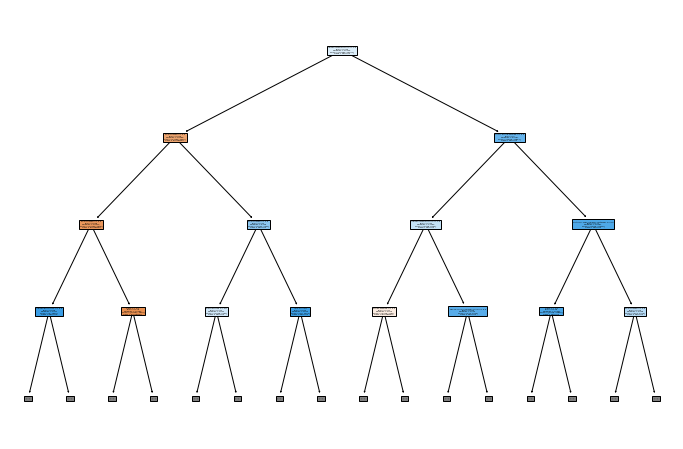

In [26]:
best_model = clf.best_estimator_

y_pred_best = best_model.predict(X_test)

accuracy_score(y_test, y_pred_best)
precision_score(y_test, y_pred_best)
recall_score(y_test, y_pred_best)
f1_score(y_test, y_pred_best)

plt.figure(figsize=(12,8))
plot_tree(
    best_model,
    max_depth=3,
    filled=True,
    feature_names=X.columns,
    class_names=["dissatisfied", "satisfied"]
)
plt.show()

Which features did the model use first to sort the samples?

The model used Inflight entertainment as the first feature to split the data, indicating that it is the most important factor in predicting customer satisfaction.

## Conclusion

**What are some key takeaways that you learned from this lab?**

This lab demonstrated the complete workflow of building a decision tree model, including data exploration, cleaning, encoding categorical variables, and splitting the dataset. It emphasized the importance of evaluating model performance using multiple metrics and interpreting results through confusion matrices and tree visualizations. Additionally, it highlighted how hyperparameter tuning can significantly improve model performance.

**What findings would you share with others?**

The analysis shows that customer satisfaction can be predicted with high accuracy using decision trees, and certain features, such as inflight entertainment, play a significant role in determining satisfaction levels.

**What would you recommend to stakeholders?**
 
It is recommended that the airline focus on improving key service factors, particularly inflight entertainment, as they have a strong impact on customer satisfaction. Additionally, implementing predictive models can help proactively identify dissatisfied customers and improve overall service quality.